<a href="https://colab.research.google.com/github/Mallikarjun-64/ML_SESSION/blob/main/session3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1. CREATING DATASETS

In [171]:
import pandas as pd
import numpy as np

In [172]:
data=[]

In [173]:
for age in range(0,101):
  if age <= 20:
    sport = "cricket"
  elif age <= 40:
    sport = "footbal"
  elif age <= 60:
    sport = "Hockey"
  elif age <= 80:
    sport = "Dogball"
  elif age <= 60:
    sport = "Hockey"
  else:
    sport = "Vollyball"
  data.append([age,sport])

In [174]:
df = pd.DataFrame(data,columns=["age","sport"])


In [175]:
print(df)

     age      sport
0      0    cricket
1      1    cricket
2      2    cricket
3      3    cricket
4      4    cricket
..   ...        ...
96    96  Vollyball
97    97  Vollyball
98    98  Vollyball
99    99  Vollyball
100  100  Vollyball

[101 rows x 2 columns]


In [176]:
df.to_csv("sport_dataset.csv")

STEP 1. DATA AUGMENTAION

In [177]:
df=pd.read_csv("sport_dataset.csv")

In [178]:
df.describe()

,Unnamed: 0,age
count,101.000000,101.000000
mean,50.000000,50.000000
std,29.300171,29.300171
min,0.000000,0.000000
25%,25.000000,25.000000
50%,50.000000,50.000000
75%,75.000000,75.000000
max,100.000000,100.000000


In [179]:
df.head(20)

,Unnamed: 0,age,sport
0,0,0,cricket
1,1,1,cricket
2,2,2,cricket
3,3,3,cricket
4,4,4,cricket
5,5,5,cricket
6,6,6,cricket
7,7,7,cricket
8,8,8,cricket
9,9,9,cricket


In [180]:
len(df)

101

In [181]:
df=df.drop_duplicates()

In [182]:
df=df.dropna()

In [183]:
df=df[(df["age"]>=1)&(df["age"]<=100)]

In [184]:
df.shape

(100, 3)

In [185]:
df.to_csv("sports_cleaned_data.csv",index=False)

In [186]:
df=pd.read_csv("sports_cleaned_data.csv")

In [187]:
df.shape

(100, 3)

In [188]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [189]:

df = pd.read_csv("sports_cleaned_data.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [190]:
x = df[["age"]]
y = df["sport"]

In [191]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [192]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)


DecisionTreeClassifier(random_state=42)

In [193]:
y_pred=model.predict(x_test)

In [194]:
accuracy=accuracy_score(y_test,y_pred)
print("accuraccy score:", accuracy)

accuraccy score: 0.95


In [195]:
Age=60
predict=model.predict([[Age]])
print(predict)

['Hockey']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [196]:
test_ages=[[15],[28],[102],[-29]]
predict=model.predict(test_ages)
print(predict)


['cricket' 'footbal' 'Vollyball' 'cricket']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


vsualilization

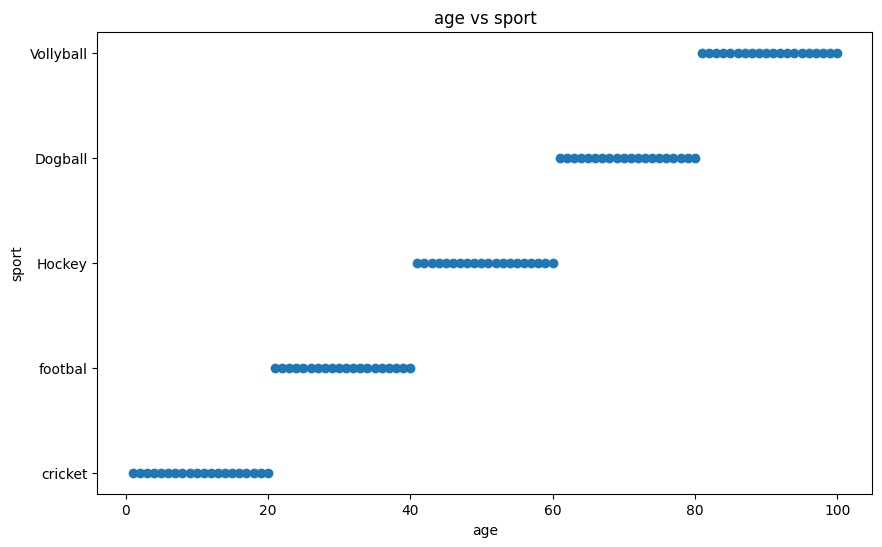

In [197]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df["age"], df["sport"])
plt.xlabel("age")
plt.ylabel("sport")
plt.title("age vs sport")
plt.show()

In [198]:
import pickle
with open("sports_model.pkl","wb") as file:
  pickle.dump(model,file)

print("model saved successfully")

model saved successfully
